In [ ]:
import pandas as pd

# Load the three files
patient = pd.read_csv("data_clinical_patient.txt", sep="\t", comment="#")
sample  = pd.read_csv("data_clinical_sample.txt",  sep="\t", comment="#")
expr    = pd.read_csv("data_mrna_seq_v2_rsem.txt", sep="\t")

# Transpose expression: genes become columns, samples become rows
expr = (expr.dropna(subset=["Hugo_Symbol"])
            .drop(columns=["Entrez_Gene_Id"], errors="ignore")
            .drop_duplicates(subset=["Hugo_Symbol"])
            .set_index("Hugo_Symbol")
            .T)
expr.index.name = "SAMPLE_ID"
expr = expr.reset_index()

# Remove duplicate columns (keep PATIENT_ID as the join key)
common = (set(sample.columns) & set(patient.columns)) - {"PATIENT_ID"}
patient = patient.drop(columns=list(common))

# Merge: sample + patient, then + expression
clinical = sample.merge(patient, on="PATIENT_ID", how="left")
final = clinical.merge(expr, on="SAMPLE_ID", how="inner")

# Sanity checks
assert final["PATIENT_ID"].is_unique, "Duplicate patients found"
print("Shape:", final.shape)
print("Expression samples matched:", len(final), "of", len(expr))

# Save
final.to_csv("STOMACH_MERGED_DATA_NEW.csv", index=False)
print("Saved STOMACH_MERGED_DATA_NEW.csv")

Shape: (412, 20567)
Expression samples matched: 412 of 412
Saved STOMACH_MERGED_DATA_NEW.csv


DATASET LOADED | Shape: (412, 20567)

Removed 3 summary leakage columns: ['MSI_SCORE_MANTIS', 'MSI_SENSOR_SCORE', 'SUBTYPE']

Tuning ELASTIC NET...
Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best CV R²: 0.6269

Tuning RANDOM FOREST...
Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best CV R²: 0.5959

Tuning XGBOOST...
Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best CV R²: 0.6324

FINAL TEST PERFORMANCE
        Model  Log_TMB_R2  Log_TMB_RMSE  Real_TMB_R2  Real_TMB_RMSE_mut_Mb  Real_TMB_MAE_mut_Mb
  Elastic Net    0.763680      0.524671     0.674909             16.105456             6.326701
      XGBoost    0.750813      0.538766     0.460038             20.756401             7.027457
Random Forest    0.721517      0.569556     0.434642             21.238922             8.028757


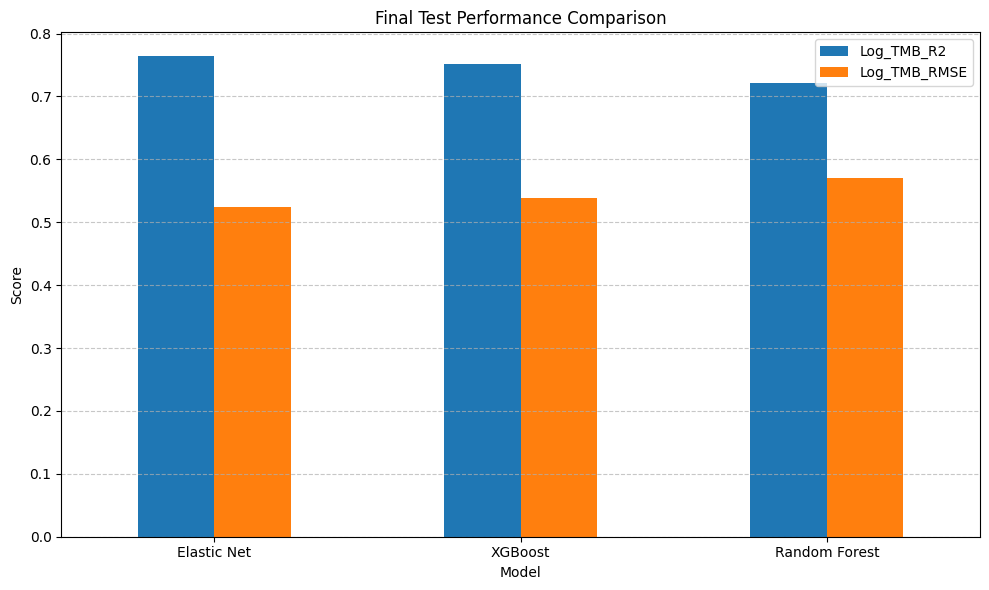

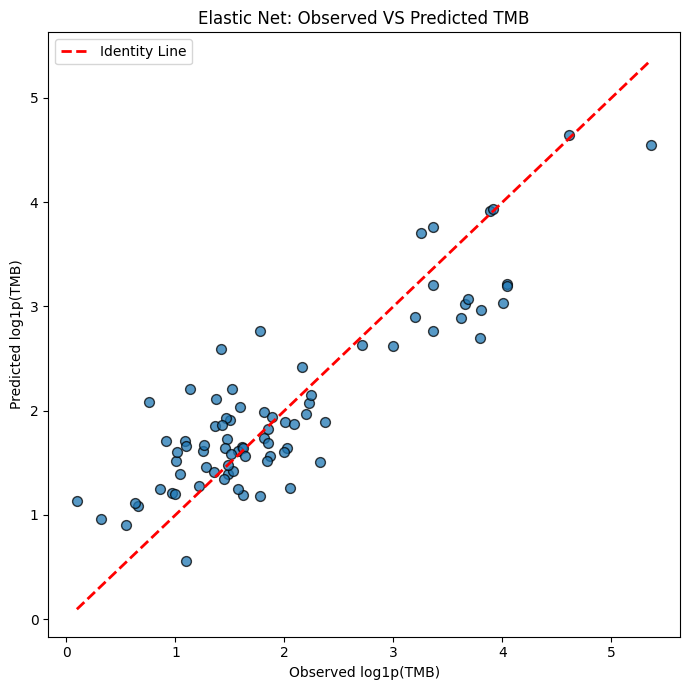


Computing Permutation Importance on Selected Features (Elastic Net)...


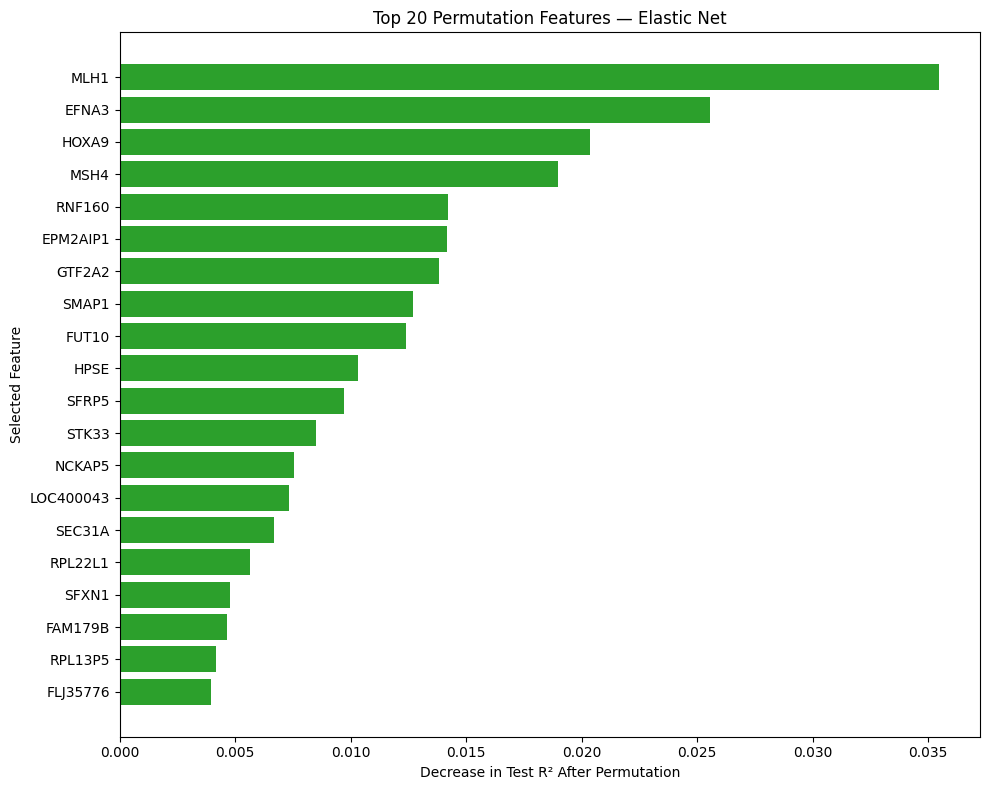


Permutation Importance completed.
Number of selected features tested: 500
Saved: Permutation_Importance_3.png

PIPELINE COMPLETED

Best model: Elastic Net

Files saved:
1. stomachTMB_Test_Results.csv
2. stomachTMB_CV_Results.csv
4. stomachTMB_Permutation_Importance.csv
5. stomachTMB_best_Parameters.csv
6. Model_comparison_1.png
7. observed_VS_predicted_2.png
9. Permutation_Importance_3.png


In [ ]:

# STOMACH TMB PREDICTION — COMPLETE PIPELINE & ARTIFAT EXPORT

import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import sparse

from sklearn.model_selection import train_test_split, KFold, RandomizedSearchCV, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer
from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_regression
from sklearn.linear_model import ElasticNet
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.inspection import permutation_importance
import xgboost as xgb

# Thread safety configuration for multi-core processing
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"


# 1. LOAD DATA
DATA_PATH = "/content/STOMACH_MERGED_DATA_NEW.csv"
if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(f"Dataset not found at {DATA_PATH}")

df = pd.read_csv(DATA_PATH)
print("=" * 70)
print(f"DATASET LOADED | Shape: {df.shape}")
print("=" * 70)


# 2. TARGET IDENTIFICATION & CLEANING
TARGET = "TMB_NONSYNONYMOUS"
if TARGET not in df.columns:
    if "TMB (nonsynonymous)" in df.columns:
        TARGET = "TMB (nonsynonymous)"
    else:
        raise ValueError(f"Target '{TARGET}' not found in dataframe columns.")

df[TARGET] = pd.to_numeric(df[TARGET], errors="coerce")
df = df.dropna(subset=[TARGET]).copy()

# Drop identifier columns
id_columns = [
    "#Patient Identifier", "Patient Identifier", "Sample Identifier",
    "Sample ID", "Patient ID", "Patient_ID", "PATIENT_ID", "Sample_ID", "SAMPLE_ID",
    "Unnamed: 0", "Unnamed: 19"
]
df.drop(columns=[c for c in id_columns if c in df.columns], inplace=True, errors="ignore")


# 3. TARGET LEAKAGE FILTERING (SUMMARY METRICS ONLY)
leakage_keywords = [
    "mutation count", "mutation_count", "total mutations", "total mutation", "subtype",
    "tumor mutational burden", "msisensor", "msi_sensor", "mantis", "hypermut", "MSI_SENSOR_SCORE"
 ]

leakage_columns = [
    col for col in df.columns
    if col != TARGET and (
        col.lower() in ["tmb", "tmb_nonsynonymous"] or
        any(key in col.lower() for key in leakage_keywords)
    )
]

if leakage_columns:
    print(f"\nRemoved {len(leakage_columns)} summary leakage columns:", leakage_columns)
    df.drop(columns=leakage_columns, inplace=True)

# 4. PREPARE FEATURES (X) AND TARGET (y)
X = df.drop(columns=[TARGET])
y = np.log1p(df[TARGET].astype(float))

numeric_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(exclude=np.number).columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

# 5. SAFE PREPROCESSING PIPELINE
def safe_log1p(x):
    return np.log1p(np.clip(x, 0, None))

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("log1p", FunctionTransformer(safe_log1p, validate=False, feature_names_out="one-to-one"))
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=True))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features)
])

cv = KFold(n_splits=3, shuffle=True, random_state=42)


# 6. MODEL PIPELINES
elastic_net = Pipeline([
    ("preprocess", preprocessor),
    ("variance", VarianceThreshold()),
    ("select_kbest", SelectKBest(f_regression)),
    ("scaler", StandardScaler(with_mean=False)),
    ("model", ElasticNet(max_iter=3000, tol=1e-3, random_state=42))
])

random_forest = Pipeline([
    ("preprocess", preprocessor),
    ("variance", VarianceThreshold()),
    ("select_kbest", SelectKBest(f_regression)),
    ("model", RandomForestRegressor(random_state=42, n_jobs=1))
])

xgboost_model = Pipeline([
    ("preprocess", preprocessor),
    ("variance", VarianceThreshold()),
    ("select_kbest", SelectKBest(f_regression)),
    ("model", xgb.XGBRegressor(objective="reg:squarederror", random_state=42, n_jobs=1, tree_method="hist"))
])


# 7. HYPERPARAMETER SEARCH GRIDS
elastic_params = {
    "variance__threshold": [0.0, 1e-5],
    "select_kbest__k": [100, 250, 500],
    "model__alpha": np.logspace(-3, 1, 10),
    "model__l1_ratio": [0.05, 0.5, 0.9]
}

rf_params = {
    "variance__threshold": [0.0, 1e-5],
    "select_kbest__k": [100, 250, 500],
    "model__n_estimators": [150, 250],
    "model__max_depth": [8, 15, None],
    "model__min_samples_split": [2, 5],
    "model__max_features": ["sqrt", 0.5]
}

xgb_params = {
    "variance__threshold": [0.0, 1e-5],
    "select_kbest__k": [100, 250, 500],
    "model__n_estimators": [150, 250],
    "model__max_depth": [2, 3, 5],
    "model__learning_rate": [0.03, 0.10],
    "model__subsample": [0.8, 1.0],
    "model__colsample_bytree": [0.5, 0.8]
}


# 8. PARALLEL MODEL TUNING
def tune_model(model, parameters, name):
    print(f"\nTuning {name}...", flush=True)
    search = RandomizedSearchCV(
        model, parameters, n_iter=10, scoring="r2", cv=cv,
        random_state=42, n_jobs=1, verbose=1
    )
    search.fit(X_train, y_train)
    print(f"Best CV R²: {search.best_score_:.4f}", flush=True)
    return search

elastic_search = tune_model(elastic_net, elastic_params, "ELASTIC NET")
rf_search = tune_model(random_forest, rf_params, "RANDOM FOREST")
xgb_search = tune_model(xgboost_model, xgb_params, "XGBOOST")

models = {
    "Elastic Net": elastic_search.best_estimator_,
    "Random Forest": rf_search.best_estimator_,
    "XGBoost": xgb_search.best_estimator_
}

# 9. CROSS-VALIDATION & TEST EVALUATION
cv_records = []
test_results = []
y_test_orig = np.expm1(y_test)

for name, model in models.items():
    # Cross-validation performance
    cv_scores = cross_validate(
        model, X_train, y_train, cv=cv,
        scoring=["r2", "neg_root_mean_squared_error", "neg_mean_absolute_error"],
        n_jobs=-1
    )
    for fold_idx in range(len(cv_scores["test_r2"])):
        cv_records.append({
            "Model": name,
            "Fold": fold_idx + 1,
            "CV_R2": cv_scores["test_r2"][fold_idx],
            "CV_RMSE": -cv_scores["test_neg_root_mean_squared_error"][fold_idx],
            "CV_MAE": -cv_scores["test_neg_mean_absolute_error"][fold_idx]
        })

    # Hold-out test evaluation
    y_pred_log = model.predict(X_test)
    y_pred_orig = np.expm1(y_pred_log)

    test_results.append({
        "Model": name,
        "Log_TMB_R2": r2_score(y_test, y_pred_log),
        "Log_TMB_RMSE": np.sqrt(mean_squared_error(y_test, y_pred_log)),
        "Real_TMB_R2": r2_score(y_test_orig, y_pred_orig),
        "Real_TMB_RMSE_mut_Mb": np.sqrt(mean_squared_error(y_test_orig, y_pred_orig)),
        "Real_TMB_MAE_mut_Mb": mean_absolute_error(y_test_orig, y_pred_orig)
    })

cv_results_df = pd.DataFrame(cv_records)
results_df = pd.DataFrame(test_results).sort_values("Log_TMB_R2", ascending=False)

print("\n" + "=" * 70)
print("FINAL TEST PERFORMANCE")
print("=" * 70)
print(results_df.to_string(index=False))

best_model_name = results_df.iloc[0]["Model"]
best_model = models[best_model_name]


# 10. PLOT 1: MODEL COMPARISON BAR CHART
plt.figure(figsize=(10, 6))
results_df.set_index("Model")[["Log_TMB_R2", "Log_TMB_RMSE"]].plot(kind="bar", ax=plt.gca())
plt.title("Final Test Performance Comparison")
plt.ylabel("Score")
plt.xlabel("Model")
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig("Model_comparison_1.png", dpi=300)
plt.show()


# 11. PLOT 2: OBSERVED VS PREDICTED SCATTER PLOT
prediction = best_model.predict(X_test)
plt.figure(figsize=(7, 7))
plt.scatter(y_test, prediction, alpha=0.75, color="tab:blue", edgecolors="k", s=50)

low = min(y_test.min(), prediction.min())
high = max(y_test.max(), prediction.max())
plt.plot([low, high], [low, high], linestyle="--", color="red", linewidth=2, label="Identity Line")

plt.xlabel("Observed log1p(TMB)")
plt.ylabel("Predicted log1p(TMB)")
plt.title(f"{best_model_name}: Observed VS Predicted TMB")
plt.legend()
plt.tight_layout()
plt.savefig("observed_VS_predicted_2.png", dpi=300)
plt.show()


# 13. PERMUTATION IMPORTANCE — SELECTED FEATURES ONLY

print(f"\nComputing Permutation Importance on Selected Features ({best_model_name})...")

X_test_selected = best_model[:-1].transform(X_test)
if sparse.issparse(X_test_selected):
    X_test_selected = X_test_selected.toarray()

selected_features = [f.split("__")[-1] for f in best_model[:-1].get_feature_names_out()]

perm = permutation_importance(
    best_model.named_steps["model"],
    X_test_selected,
    y_test,
    scoring="r2",
    n_repeats=5,
    random_state=42,
    n_jobs=-1
)

permutation_importance_df = pd.DataFrame({
    "Feature": selected_features,
    "Importance_Mean": perm.importances_mean,
    "Importance_SD": perm.importances_std
}).sort_values("Importance_Mean", ascending=False)

top_perm = permutation_importance_df.head(20).sort_values("Importance_Mean")

# PLOT : Permutation Feature Importance Plot

plt.figure(figsize=(10, 8))
plt.barh(top_perm["Feature"], top_perm["Importance_Mean"], color="tab:green")
plt.xlabel("Decrease in Test R² After Permutation")
plt.ylabel("Selected Feature")
plt.title(f"Top 20 Permutation Features — {best_model_name}")
plt.tight_layout()
plt.savefig("Permutation_Importance_3.png", dpi=300, bbox_inches="tight")
plt.show()

print("\nPermutation Importance completed.")
print(f"Number of selected features tested: {len(selected_features)}")
print("Saved: Permutation_Importance_3.png")


# 14. SAVE RESULTS AND ARTIFACTS
results_df.to_csv("stomachTMB_Test_Results.csv", index=False)
cv_results_df.to_csv("stomachTMB_CV_Results.csv", index=False)
permutation_importance_df.to_csv("stomachTMB_Permutation_Importance.csv", index=False)

# Format and export best hyperparameter configurations
best_parameters = []
for name, search in [
    ("Elastic Net", elastic_search),
    ("Random Forest", rf_search),
    ("XGBoost", xgb_search)
]:
    for parameter, value in search.best_params_.items():
        best_parameters.append({
            "Model": name,
            "Parameter": parameter,
            "Best_Value": value
        })

pd.DataFrame(best_parameters).to_csv("stomachTMB_best_Parameters.csv", index=False)


# 15. FINAL SUMMARY
print("\n" + "=" * 70)
print("PIPELINE COMPLETED")
print("=" * 70)
print("\nBest model:", best_model_name)
print("\nFiles saved:")
print("1. stomachTMB_Test_Results.csv")
print("2. stomachTMB_CV_Results.csv")
print("4. stomachTMB_Permutation_Importance.csv")
print("5. stomachTMB_best_Parameters.csv")
print("6. Model_comparison_1.png")
print("7. observed_VS_predicted_2.png")
print("9. Permutation_Importance_3.png")